Reference from [Introduction to Spherical Harmonics for Graphics Programmers](https://gpfault.net/posts/sph.html)

# Spherical Harmonics

Any function that associates some quantity/value with a direction in 3D space can be thought of as a function defined on the domain of a `unit sphere`. Indeed, a "direction" is a unit vector, and the endpoint of that vector is always some point on the surface of a unit sphere centered at the origin.  

It just so happens that any continuous function defined on a sphere can be represented as an infinite weighted sum of some special polynomials. Those polynomials are, in fact, what we call "spherical harmonics". By truncating that sum and making it finite, we can approximate the function in question.  

Being able to approximate a potentially complex lighting environment by just summing up some polynomials is a very appealing proposition. But things other than lighting can be expressed as functions defined on a sphere too.

# Spherical Harmonics Functions

Spherical harmonic functions (or just “spherical harmonics” for short) are an infinite set of special functions defined on the surface of a sphere that form an orthonormal basis for the entire space of continuous functions defined on a sphere.  

It means that a continuous function defined on the sphere, no matter how complicated or difficult to evaluate, can be expressed as an infinite weighted sum of spherical harmonic functions.

# Spherical Harmonic Degree and Order

SH functions are split into numbered groups often called `“frequency bands”`. Each band has a number $l \in 0,\ 1,\ 2, ...$  associated with it. This number is called the "degree" of the functions within the band. The band with degree $l$ contains $2l+1$  functions. By convention, the functions within a band of degree $l$ are indexed from $-l$ to $l$, and that index is called the “order” of the function.

A spherical harmonic function with degree $l$ and order $m$ is usually denoted like
$$Y_l^m$$

In [2]:
import math
import numpy as np
import random

In [3]:
RECIP_PI = 1/math.pi
C = [
math.sqrt(RECIP_PI) * 0.5,
math.sqrt(3 * RECIP_PI) * 0.5,
math.sqrt(15 * RECIP_PI) * 0.5,
math.sqrt(5 * RECIP_PI) * 0.25,
math.sqrt(15 * RECIP_PI) * 0.25,
math.sqrt(70 * RECIP_PI) * 0.125,
math.sqrt(105 * RECIP_PI) * 0.5,
math.sqrt(42 * RECIP_PI) * 0.125,
math.sqrt(7 * RECIP_PI) * 0.25,
math.sqrt(105 * RECIP_PI) * 0.25
]
print(C)

[0.28209479177387814, 0.4886025119029199, 1.0925484305920792, 0.31539156525252005, 0.5462742152960396, 0.5900435899266435, 2.890611442640554, 0.4570457994644658, 0.3731763325901154, 1.445305721320277]


In [4]:
# SH basis functions up to degree l=3. 
# Source for SH basis function definitions:
# "Stupid Spherical Harmonics Tricks", Peter-Pike Sloan, 2008
def y00(x,y,z): return C[0] 
def y_11(x,y,z): return C[1] * y
def y01(x,y,z): return C[1] * z 
def y11(x,y,z): return C[1] * x
def y_22(x,y,z): return C[2] * y * x
def y_12(x,y,z): return C[2] * y * z
def y02(x,y,z): return C[3] * (3 * z * z - 1.0)
def y12(x,y,z): return C[2] * x * z
def y22(x,y,z): return C[4] * (x*x - y*y)
def y_33(x,y,z): return C[5] * y * (3*x*x - y*y)
def y_23(x,y,z): return C[6] * z * (y*x)
def y_13(x,y,z): return C[7] * y * (5*z*z -1)
def y03(x,y,z): return C[8] * z * (5*z*z - 3)
def y13(x,y,z): return C[7] * x * (5 * z * z - 1)
def y23(x,y,z): return C[9] * z * (x*x - y*y)
def y33(x,y,z): return C[5] * x * (x*x - 3*y*y)

In [5]:
# Evaluates SH basis functions with degrees up to and including l for the
# given direction d, returning the result as a Float32 array where each
# element is the value of the corresponding basis function.
# Only supports values of l <= 3.
def evalSHBasis(d, l):
  x = d[0]
  y = d[1]
  z = d[2]
  if l == 0:
      return np.array([y00(x, y, z)], dtype=np.float32)
  elif l == 1:
      return np.array([
        y00(x, y, z),  # l = 0
        y_11(x, y, z), # l = 1
        y01(x, y, z),
        y11(x, y, z)
    ], dtype=np.float32)
  elif l == 2:
      return np.array([
        y00(x, y, z),  # l = 0
        y_11(x, y, z), # l = 1
        y01(x, y, z),
        y11(x, y, z),
        y_22(x, y, z), # l = 2
        y_12(x, y, z),
        y02(x, y, z),
        y12(x, y, z),
        y22(x, y, z)
    ], dtype=np.float32)
  else:
      return np.array([
        y00(x, y, z),  # l = 0
        y_11(x, y, z), # l = 1
        y01(x, y, z),
        y11(x, y, z),
        y_22(x, y, z), # l = 2
        y_12(x, y, z),
        y02(x, y, z),
        y12(x, y, z),
        y22(x, y, z),
        y_33(x, y, z), # l = 3
        y_23(x, y, z),
        y_13(x, y, z),
        y03(x, y, z),
        y13(x, y, z),
        y23(x, y, z),
        y33(x, y, z)
    ], dtype=np.float32)

In [6]:
# SH 계수들에 스칼라 값을 곱하기 위한 도우미 함수
def mul_scalar_by_sh_coeffs(scalar, coeffs):
    # numpy 배열을 사용하면 for문이나 map 없이 스칼라 곱셈이 바로 적용됩니다.
    return scalar * coeffs

# 두 SH 계수들의 묶음을 더하기 위한 도우미 함수
def add_sh_coeffs(coeffs0, coeffs1):
    if len(coeffs0) == 0:
        return np.copy(coeffs1)
    # 배열 간의 덧셈도 직관적으로 바로 처리됩니다.
    return coeffs0 + coeffs1

# 기저 함수들이 정규 직교임을 검증하기 위해 간단한 몬테-카를로 적분을 사용
def test_basis_functions():
    num_samples = 100000
    num_basis_funcs = 16 # l=3까지 지원하므로 총 16개의 함수
    
    # inner_products[i]는 i-번째 SH 기저 함수를 자기자신을 포함한,
    # 다른 SH 기저 함수와 내적한 결과를 가지고 있음.
    # 초기값 0으로 채워진 크기 16의 numpy 배열 16개를 리스트로 생성합니다.
    inner_products = [np.zeros(num_basis_funcs, dtype=np.float32) for _ in range(num_basis_funcs)]
    
    s = 0
    while s < num_samples:
        # 구 상의 랜덤한 점을 생성하기 위해 간단한 기각 샘플링을 사용함:
        # * [-1, -1, -1] - [1, 1, 1] 큐브 내에서의 점을 생성하고
        # * 만약 점이 단위 구(원) 내부에 있다면, 정규화하고 해당 점을 사용함;
        # * 그렇지 않다면, 다시 시도함.
        xr = random.uniform(-1.0, 1.0)
        yr = random.uniform(-1.0, 1.0)
        zr = random.uniform(-1.0, 1.0)
        n = math.sqrt(xr*xr + yr*yr + zr*zr)
        
        if n > 1.0:
            continue
            
        s += 1
        d = np.array([xr/n, yr/n, zr/n], dtype=np.float32)
        
        # 생성된 샘플 지점에서의 SH 기저 함수를 계산하고
        # (외부에 eval_sh_basis 함수가 정의되어 있다고 가정합니다)
        basis_function_values = evalSHBasis(d, 3)
        
        # 부분 내적을 계산한 다음 총합에 더해줌.
        for b in range(num_basis_funcs):
            bv = basis_function_values[b]
            # numpy 배열에 스칼라 bv를 곱하여 배열 전체를 갱신합니다.
            partial_inner_products = basis_function_values * bv
            inner_products[b] = add_sh_coeffs(inner_products[b], partial_inner_products)
            
    # 몬테-카를로 적분의 마지막 단계: 적분 영역의 크기를 곱해주고 (단위 구의 경우 4pi)
    # 샘플의 수로 나눠줌.
    for b in range(num_basis_funcs):
        inner_products[b] = mul_scalar_by_sh_coeffs(4 * math.pi / num_samples, inner_products[b])
        
    # inner_products[i][j]에서 i == j인 경우엔 1에 아주 가까워야 하며,
    # i != j인 경우(서로 다른 기저 함수)엔 0에 아주 가까워야 합니다. (정규 직교성)
    for row in inner_products:
        print(row)

# 함수 실행을 위한 호출 (evalSHBasis가 구현되어 있을 때 정상 작동합니다)
test_basis_functions()

[ 1.0001496e+00 -1.8142130e-03  9.6235201e-03 -3.4822340e-03
  3.9495216e-03  4.7987686e-03 -3.3687719e-04 -5.2274433e-03
  1.1874980e-03  1.8668937e-03 -1.7382880e-03  9.8745117e-04
 -6.0466955e-05  4.7432012e-03  1.1124364e-03 -2.7310974e-03]
[-1.8142130e-03  9.9921668e-01  3.7170956e-03  3.0593129e-03
 -1.4895666e-03  6.7566982e-03  1.5194791e-03 -1.1379562e-03
  3.1065638e-03 -3.8050136e-03 -4.6878620e-03 -2.4382931e-03
 -2.3579050e-03 -2.8027960e-03 -5.5545082e-05 -6.4372807e-03]
[ 9.6235201e-03  3.7170956e-03  9.9968946e-01 -4.0492052e-03
 -1.1379531e-03 -5.8761425e-04  8.5543506e-03  1.2304442e-03
  7.2824938e-04  2.4957913e-03  7.4522577e-05  4.0660612e-03
  1.6132429e-04 -1.8999510e-03  3.5128379e-03  4.0628886e-04]
[-3.4822340e-03  3.0593129e-03 -4.0492052e-03  1.0010567e+00
 -1.1287207e-04 -1.1379555e-03  4.9588918e-03  8.2131783e-03
 -5.8689686e-03  9.2117535e-04  6.1689550e-03 -2.8027969e-03
  4.6339217e-03  1.3951734e-03 -3.6926297e-03  4.5924895e-03]
[ 3.9495216e-03 -1.4

# Spherical Harmonic Definition

If you look up “spherical harmonic basis functions”, or try some math textbook, you might encounter this scary beast as the definition of the spherical harmonic function of degree $l$ and order $m$ :

$$Y_l^m(\theta,\ \phi) = (-1)^m \sqrt{\frac{(2l+1)}{4\pi}\frac{(l-m)!}{(l+m)!}}P_l^m(cos\theta)e^{im\phi}$$

This is not the form that is usually used in computer graphics. However, the form that we do use contains all of the same building blocks.  


First thing to notice about $Y_l^m$ is that it is a function defined in terms of spherical coordinates.

Now is a good time to establish some coordinate system conventions. Doing so is quite important. Different authors might assume different conventions. So, for example, when you're copying and pasting code, you have to be aware of the original convention that was used, and what the target code that you're pasting into assumes.

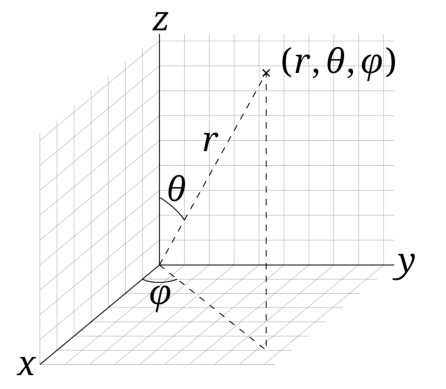

In [7]:
import matplotlib.pyplot as plt
img = plt.imread("For_SH/coord-sys.png")
plt.axis('off')
plt.imshow(img);

We will assume that the angle $\theta$ is the angle between $Z$ axis and our direction vector and $\phi$ is the angle between the $X$ axis and the projection of our direction vector onto the $XY$ plane. So, the conversion from spherical to Cartesian coordinates is:
$$\begin{align} &x = cos\phi sin\theta \\ &y=sin\phi sin\theta \\ &z=cos\theta \end{align}$$

Hint: The equation above was quite hard for me to accept but by doing $sin\theta$ first on $x,\ y$ it was acceptable

## -1 at the front of equation

About $(-1)^m$ from the equation, it is removable since it doesn't change "basisness" or other properties of SH at all.

## sqrt

Next, let's see what this equation does.
$$\sqrt{\frac{(2l+1)}{4\pi}\frac{(l-m)!}{(l+m)!}}$$

It looks unwieldy with the square root and the factorials, but there isn’t much special going on here: ultimately, it’s just a constant needed for normalization (remember, the SH basis is orthonormal). Meaning, if we removed this constant, the inner product $<Y_l^m,Y_l^m>$ would no longer equal 1.

## $P_l^m(cos\theta)$

Next, we will examine the mysterious $P_l^m(cos\theta)$

This is something called an “associated Legendre polynomial”, or an "associated Legendre function". The  $m$ is actually a superscript, not an exponentiation operation!  
In the context of spherical harmonic functions, the part containing the associated Legendre polynomial defines how the function changes from pole to pole (because it depends on the polar angle theta).

Formally,
$$P_l^m(x)=(1-x^2)^{\frac{m}{2}}\frac{d^m}{dx^m}P_l(x)\ when\ m\ge0\\P_l^m(x)=\frac{(l-m)!}{(l+m)!}P_l^{-m}(x)\ \ when\ m\lt0$$

Where $P_l^m(x)$ is the Legendre polynomial (the not associated kind), which is given by the formula:

$$P_l^m(x) = \frac{1}{2^ll!}\frac{d^l}{dx^l}[(x^2-1)^l]

Just for the sake of practice, we can try deriving $P_1^1(x)$ :

$$P_1(x)=\frac{1}{2}[\frac{d}{dx}(x^2-1)]=\frac{1}{2}(2x)=x\\ P_1^1(x)=\sqrt{(1-x^2)}\frac{d}{dx}P_1(x)=\sqrt{(1-x^2)}\frac{d}{dx}x=\sqrt{(1-x^2)}$$

For use in spherical harmonics we substitute $x$ with $cos\theta$:
$$P_1^1(cos\theta) = \sqrt{1-cos^2\theta}=\sqrt{sin^2\theta}=sin\theta

You get the idea. We don't actually need to derive every associated Legendre function. The list below should have you covered for pretty much any application in computer graphics:

$$
\begin{align}
&P_0^0(cos\theta) = 1\\ &P_1^0(cos\theta) = cos\theta\\ &P_1^1(cos\theta) = sin\theta\\ &P_2^0(cos\theta) = \frac{1}{2}(3cos^2\theta-1) \\ &P_2^1(cos\theta) = 3cos\theta sin\theta\\ &P_2^2(cos\theta) = 3sin^2\theta\\ &P_3^0(cos\theta) = \frac{1}{2}(5cos^3\theta-3cos\theta)\\ &P_3^1(cos\theta) = \frac{3}{2}(5cos^2\theta - 1)sin\theta\\ &P_3^2(cos\theta) = 15cos\theta sin^2\theta\\ &P_3^3(cos\theta) = 15sin^3\theta\\ &P_4^0(cos\theta) = \frac{1}{8}(35cos^4\theta - 30cos^2\theta+3)\\ &P_4^1(cos\theta) = \frac{5}{2}(7cos^3\theta-3cos\theta)sin\theta \\ &P_4^2(cos\theta) = \frac{15}{2}(7cos^2\theta-1)sin^2\theta \\ &P_4^3(cos\theta) = 105cos\theta sin^3\theta \\ &P_4^4(cos\theta) = 105sin^4\theta
\end{align}
$$

## $e^{im\phi}$

This defines how the SH function behaves with the changing of the azimuthal angle $\phi$. And if you know the famous Euler formula, you’ll know that this equals $cos(m\phi)+isin(m\phi)$ where $i^2=-1$.

The emergence of complex numbers in this way is the reason why different forms of SH are used in graphics. In computer graphics, we don't usually deal with complex numbers.  
Luckily there exists a more convenient definition for real-valued functions. Moreover, complex-valued spherical harmonics can be expressed in terms of real-valued ones, and vice versa.

# Actual Definition of SH used in computer graphics

A nice, concise and to-the-point statement of real-valued spherical harmonic functions can be found in this excerpt from Robin Green's paper:

...the SH function is traditionally represented by the symbol y:
$$y_l^m(\theta,\phi)=
\begin{cases}
\sqrt{2}K_l^mcos(m\phi)P_l^m(cos\theta) & \text{if }\  m\gt0\\
K_l^0P_l^0(cos\theta) & \text{if }\ m=0\\
\sqrt{2}K_l^msin(-m\phi)P_l^{-m}(cos\theta) & \text{if }\ m\lt0
\end{cases}

where $P_l^m$ is the same associated Legendre polynomials we look at earlier and $K_l^m$ is just a scaling factor to normalize the functions:
$$K_l^m = \sqrt{\frac{(2l+1)}{4\pi}\frac{(l-|m|)!}{(l+|m|)!}}$$

# Fourier and SH

Fourier transform and Spherical Harmonics have propertiess that are similar so we are going to look at both

## Understanding the Underlying Space

### Fourier

__Space__: ${f:[0,a]->R}$  
__Input Space__: One-dimensional line segment  
__Output Space__: Real Number

### SH

__Space__: ${f:S^2->R}$  
__Input Space__: Direction made with latitude($\theta$) and longitude($\phi$)  
__Output Space__: Real Number

## Orthogonality

This means that blocks of different shapes are completely independent and do not mix.

### Fourier

If you multiply two sine waves with different frequencies and integrate them (calculate the area) over one period ($[0, 2\pi]$), the result is always zero.

$$ \int_{0}^{2\pi} e^{imx} \cdot (e^{inx})^* dx = 0 \quad (when\ m \neq n) $$

Code below shows this

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

Integral result of the product of sine waves with frequencies 2 and 3:
0.000000000000000


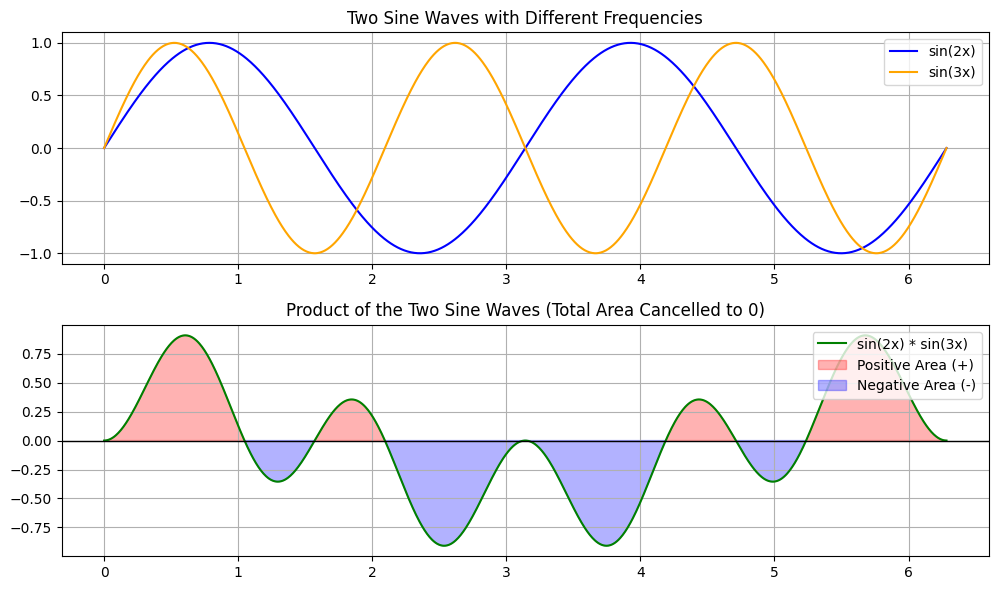

In [9]:
# 1. Setting Frequencies (Two different integer frequencies)
m = 2  
n = 3  

# 2. Define the function to be integrated: sin(mx) * sin(nx)
def integrand(x, m, n):
    return np.sin(m * x) * np.sin(n * x)

# 3. Perform numerical integration (from 0 to 2pi)
# The quad function returns a tuple of (integral result, error)
integral_result, error = quad(integrand, 0, 2 * np.pi, args=(m, n))

print(f"Integral result of the product of sine waves with frequencies {m} and {n}:")
print(f"{integral_result:.15f}") # The result is essentially 0 within floating-point error.

# 4. Prepare data for visualization
x = np.linspace(0, 2 * np.pi, 1000)
y1 = np.sin(m * x)
y2 = np.sin(n * x)
y_product = y1 * y2

# 5. Plot the graphs
plt.figure(figsize=(10, 6))

# Top graph: Two sine waves with different frequencies
plt.subplot(2, 1, 1)
plt.plot(x, y1, label=f'sin({m}x)', color='blue')
plt.plot(x, y2, label=f'sin({n}x)', color='orange')
plt.title('Two Sine Waves with Different Frequencies')
plt.legend(loc='upper right')
plt.grid(True)

# Bottom graph: The new wave formed by multiplying the two sine waves and its area
plt.subplot(2, 1, 2)
plt.plot(x, y_product, label=f'sin({m}x) * sin({n}x)', color='green')

# Color the positive area in red and the negative area in blue
plt.fill_between(x, y_product, where=(y_product > 0), color='red', alpha=0.3, label='Positive Area (+)')
plt.fill_between(x, y_product, where=(y_product < 0), color='blue', alpha=0.3, label='Negative Area (-)')

plt.axhline(0, color='black', linewidth=1)
plt.title('Product of the Two Sine Waves (Total Area Cancelled to 0)')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

### SH

If you multiply two spherical harmonics with different shapes ($l, m$) and integrate the product over the entire sphere ($S^2$), the result is always zero.

$$ \int_{S^2} Y_l^m(\theta, \phi) \cdot (Y_{l'}^{m'}(\theta, \phi))^* d\Omega = 0 \quad (if\ l \neq l', m \neq m')\\ \int_{0}^{2\pi}\int_{0}^{\pi}Y_{l_1}^{m_1}(\theta,\phi) \overline{Y_{l_2}^{m_2}(\theta,\phi)}sin(\phi)d\phi d\theta=0 $$

In [10]:
import numpy as np
from scipy.special import sph_harm
from scipy.integrate import dblquad

In [11]:
# 1. Setting SH basis degree (l) and order (m)
l1, m1 = 1, 0
l2, m2 = 2, 1

# 2. Define the function to be integrated
# SciPy's sph_harm(m, n, theta, phi) where n represents the degree (l)
# theta: theta: azimuthal angle (0 to 2π), phi: polar angle (0 to π)
def integrand_real(phi, theta):
    # First SH basis
    y1 = sph_harm(m1, l1, theta, phi)
    # Second SH basis conjugate
    y2 = np.conj(sph_harm(m2, l2, theta, phi))
    
    # Multiply by the surface element sin(phi)
    val = y1 * y2 * np.sin(phi)
    return val.real

def integrand_imag(phi, theta):
    y1 = sph_harm(m1, l1, theta, phi)
    y2 = np.conj(sph_harm(m2, l2, theta, phi))
    val = y1 * y2 * np.sin(phi)
    return val.imag

# 3. Perform double spherical integration.
# Integrate theta from 0 to 2π and phi from 0 to π.
result_real, error_real = dblquad(integrand_real, 0, 2 * np.pi, lambda x: 0, lambda x: np.pi)
result_imag, error_imag = dblquad(integrand_imag, 0, 2 * np.pi, lambda x: 0, lambda x: np.pi)

print(f"[{l1}, {m1}] 과 [{l2}, {m2}] 기저의 직교성 검증:")
print(f"적분 결과 (실수부): {result_real:.4e}")
print(f"적분 결과 (허수부): {result_imag:.4e}")

[1, 0] 과 [2, 1] 기저의 직교성 검증:
적분 결과 (실수부): -6.5398e-17
적분 결과 (허수부): 4.1939e-17


## Basis

It means that by adding an infinite number of terms perfectly reconstructs the original form, however complex it may be.

### Fourier

When generating a square wave, adding sine waves—starting with one and progressing to three, ten, and then a hundred—causes the waveform to converge toward a perfect square shape.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [13]:
# 1. x축 데이터 생성 (0부터 4pi까지, 2주기 분량)
x = np.linspace(0, 4 * np.pi, 1000)

# 2. 완벽한 목표 사각파 (비교용)
# sin(x)의 부호를 추출하여 -1과 1을 오가는 사각파를 만듭니다.
y_square = np.sign(np.sin(x))

# 3. 그래프 초기 설정
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y_square, color='gray', linestyle='--', linewidth=2, label='Target Square Wave')
line, = ax.plot([], [], color='red', linewidth=2, label='Fourier Approximation')

ax.set_xlim(0, 4 * np.pi)
ax.set_ylim(-1.5, 1.5)
ax.set_title("Fourier Series Approximation of a Square Wave")
ax.set_xlabel("x")
ax.set_ylabel("Amplitude")
ax.grid(True)
ax.legend(loc="upper right")

# 4. 애니메이션 업데이트 함수
def update(frame):
    # frame은 더할 사인파의 개수 (1, 2, 3, ...)
    y_approx = np.zeros_like(x)
    
    # 사각파는 홀수 차수(1, 3, 5, ...)의 사인파만 사용합니다.
    for i in range(frame):
        n = 2 * i + 1  # 1, 3, 5, 7...
        y_approx += (4 / np.pi) * (np.sin(n * x) / n)
        
    line.set_data(x, y_approx)
    ax.set_title(f"Fourier Series Approximation (N = {frame} terms)")
    return line,

# 5. 애니메이션 실행 (1개부터 50개의 항까지 더해가는 과정 시각화)
# interval: 프레임 간의 시간 간격 (밀리초 단위, 200ms = 0.2초)
ani = FuncAnimation(fig, update, frames=range(1, 51), interval=200, blit=True)

plt.close()
HTML(ani.to_jshtml())

### SH

When reconstructing an environment map (lighting texture) that features sharp highlights, the result becomes increasingly distinct—closely resembling the original—as the order increases from $l=0$ (constant, 1 component) to $l=1$ (4 components) and $l=2$ (9 components).

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.special import sph_harm
from PIL import Image


Loading image...
Image loaded and computed in 64x128 resolution.
Starting SH encoding (l=0 to 10)... This process may take some time.
 Computing degree l=0 ...
 Computing degree l=1 ...
 Computing degree l=2 ...
 Computing degree l=3 ...
 Computing degree l=4 ...
 Computing degree l=5 ...
 Computing degree l=6 ...
 Computing degree l=7 ...
 Computing degree l=8 ...
 Computing degree l=9 ...
 Computing degree l=10 ...
Encoding completed! Time taken: 0.1 seconds
Displaying reconstructed images for different SH degrees.


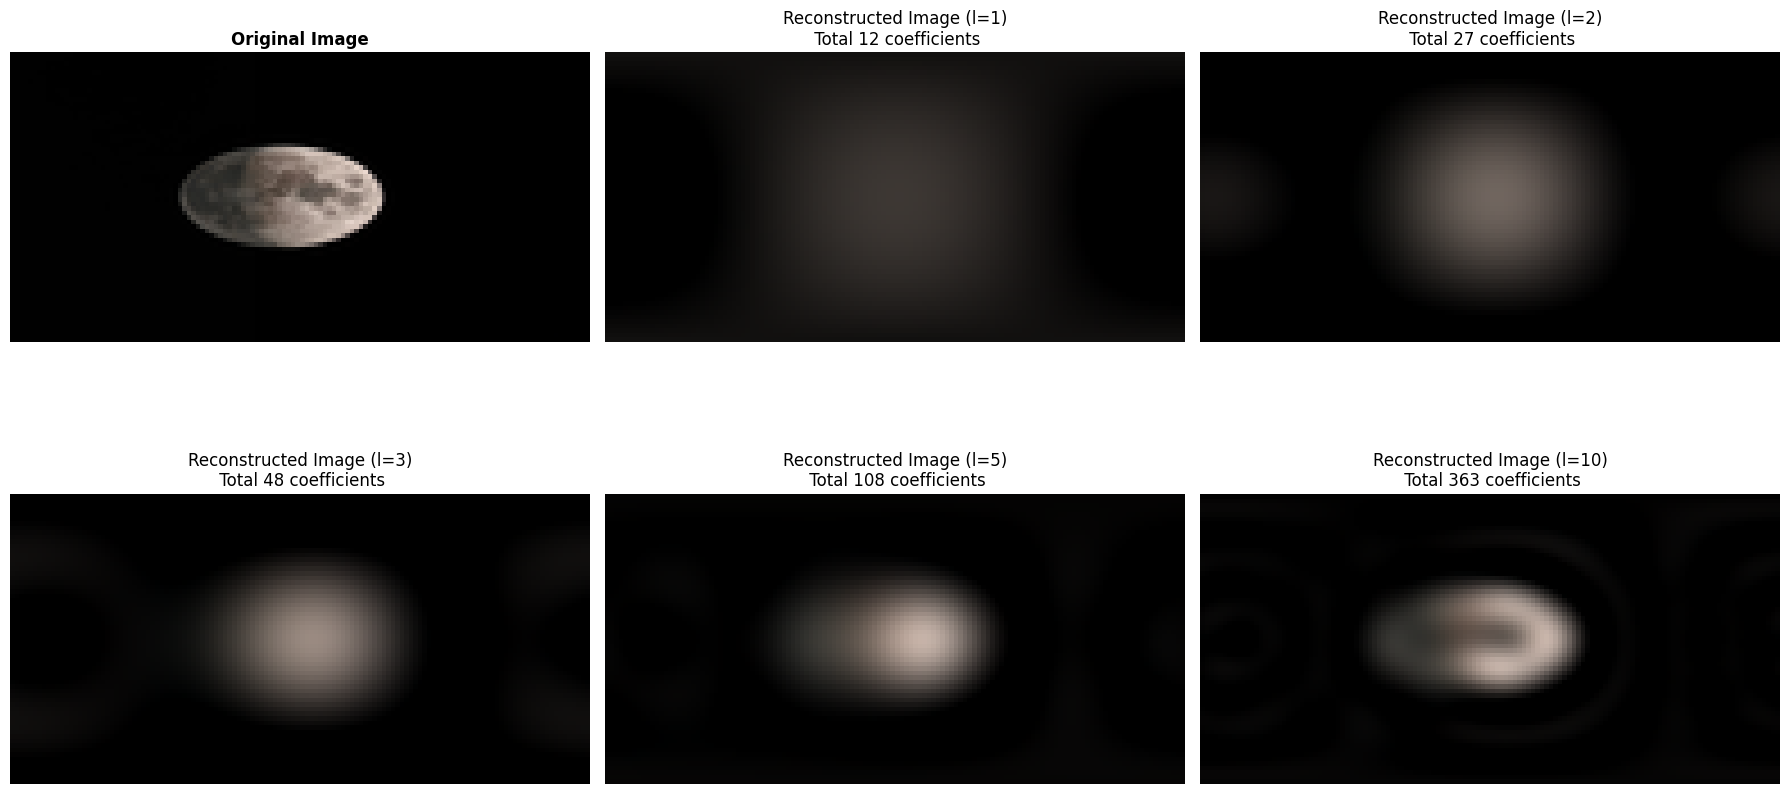

In [33]:
# ==========================================
# 1. Setting and Image Loading
# ==========================================
# Resize the image to a very small size for faster computation
PROCESS_H, PROCESS_W = 64, 128 
MAX_L = 10 # Maximum SH degree to compute

# Load the image from my folder gaussian-splatting-for-practice\For_SH
# Image is from unsplash.com, artist: Nicolo Caredda
print("Loading image...")
img_path = "For_SH/Moon.jpg" # HDR image for Spherical Harmonics computation
img_original = Image.open(img_path).convert("RGB")

# Resize the image to PROCESS_H x PROCESS_W for faster computation
img_resized = img_original.resize((PROCESS_W, PROCESS_H), Image.LANCZOS)
img_array = np.array(img_resized) / 255.0 # Normalize pixel values to [0, 1]
print(f"Image loaded and computed in {img_array.shape[0]}x{img_array.shape[1]} resolution.")

# ==========================================
# 2. Setting up spherical coordinates and integration preparation
# ==========================================
phi = np.linspace(0,np.pi, PROCESS_H) # Polar angle [0, π]
theta = np.linspace(0, 2*np.pi, PROCESS_W) # Azimuthal angle [0, 2π]
theta_grid, phi_grid = np.meshgrid(theta, phi) # Width first, Height second

# Unit source for spherical integration: (sin(phi) * dphi * dtheta)
d_theta= 2*np.pi/PROCESS_W
d_phi = np.pi/PROCESS_H
solid_angle = np.sin(phi_grid) *d_theta* d_phi

# ==========================================
# 3. Encoding SH coefficients for each RGB channel
# ==========================================
print(f"Starting SH encoding (l=0 to {MAX_L})... This process may take some time.")
# 계수를 저장할 딕셔너리 구조: sh_coeffs[채널][(l, m)]
sh_coeffs = [{}, {}, {}] # R, G, B 채널용

start_time = time.time()

for l in range(MAX_L + 1):
    print(f" Computing degree l={l} ...")
    for m in range(-l, l + 1):
        # SH 기저 함수 계산
        Y = sph_harm(m, l, theta_grid, phi_grid)
        Y_conj = np.conj(Y) # Y_l^m(theta, phi) conjugate
        
        # R, G, B 각 채널에 대해 적분 수행
        for channel in range(3):
            data = img_array[:, :, channel] # f(theta, phi) for the current channel(R, G, B)
            # C_lm = 적분( I * conj(Y) * sin(phi) )
            c = np.sum(data * Y_conj * solid_angle)
            sh_coeffs[channel][(l, m)] = c

print(f"Encoding completed! Time taken: {time.time() - start_time:.1f} seconds")

# ==========================================
# 4. Function for SH decoding (reconstruction by degree)
# ==========================================
def reconstruct_image(target_L):
    recon_img = np.zeros((PROCESS_H, PROCESS_W, 3))
    
    for l in range(target_L + 1):
        for m in range(-l, l + 1):
            Y = sph_harm(m, l, theta_grid, phi_grid)
            for channel in range(3):
                recon_img[:, :, channel] += (sh_coeffs[channel][(l, m)] * Y).real
                
    # 복원 과정에서 발생하는 부동소수점 오차로 인한 0~1 범위를 벗어나는 값 클리핑
    return np.clip(recon_img, 0, 1)

# ==========================================
# 5. Result Visualization
# ==========================================
target_degrees = [1, 2, 3, 5, 10]
n_rows = 2
n_cols = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()

# Print original image
axes[0].imshow(img_array)
axes[0].set_title("Original Image", fontweight ='bold')
axes[0].axis('off')

# Print reconstructed images for each target degree
for idx, L in enumerate(target_degrees):
    recon_img = reconstruct_image(L)
    ax = axes[idx +1]
    ax.imshow(recon_img)

    num_coeffs = (L+1)**2*3 # Total number of SH coefficients for RGB channels
    ax.set_title(f"Reconstructed Image (l={L})\n Total {num_coeffs} coefficients")
    ax.axis('off')

plt.tight_layout()
print("Displaying reconstructed images for different SH degrees.")
plt.show()

## Parseval's Theorem / Plancherel Theorem

The inner product is preserved.  
This means that the computationally heavy "integral" operation in the original function space is perfectly replaced by a lightweight "vector dot product" operation in the coefficient space.

### Fourier
The value obtained by multiplying and integrating two signals $f(x)$ and $g(x)$ is equal to the sum of the products of the coefficient arrays $c_m$ and $d_m$ obtained by their respective Fourier transforms.

### SH



In [16]:
import numpy as np
import time
from scipy.special import sph_harm

In [17]:
# 1. 고해상도 구면 픽셀 설정 (1000 x 2000 해상도 = 200만 개의 픽셀)
H, W = 1000, 2000
phi = np.linspace(0, np.pi, H)
theta = np.linspace(0, 2*np.pi, W)
theta_grid, phi_grid = np.meshgrid(theta, phi)

# 구면 적분을 위한 픽셀당 면적 요소 (d_theta * d_phi * sin(phi))
d_theta = 2 * np.pi / W
d_phi = np.pi / H
solid_angle = np.sin(phi_grid) * d_theta * d_phi

# 2. 가상의 조명(A)과 재질(B)을 정의하기 위한 SH 계수 (l=2까지, 총 9개)
# 실제 게임 엔진에서는 라이트 빌드 과정에서 이 계수들을 미리 계산해 둡니다.
np.random.seed(42)
coeffs_A = np.random.rand(9) + 1j * np.random.rand(9)
coeffs_B = np.random.rand(9) + 1j * np.random.rand(9)

# 계수를 바탕으로 200만 픽셀짜리 조명 맵과 재질 맵 생성 (Pre-computation)
print("200만 픽셀 해상도의 빛 환경(A)과 재질(B) 맵을 생성 중입니다...\n")
A_map = np.zeros((H, W), dtype=np.complex128)
B_map = np.zeros((H, W), dtype=np.complex128)

idx = 0
for l in range(3):
    for m in range(-l, l+1):
        Y = sph_harm(m, l, theta_grid, phi_grid)
        A_map += coeffs_A[idx] * Y
        B_map += coeffs_B[idx] * Y
        idx += 1

# =====================================================================
# [실험 1] 공간 영역 (Spatial Domain): 무식하게 픽셀 단위로 몽땅 곱해서 적분
# =====================================================================
start_spatial = time.perf_counter()

# A 픽셀 * B 픽셀 * 면적 가중치를 200만 번 연산하여 모두 더함
spatial_result = np.sum(A_map * np.conj(B_map) * solid_angle)

time_spatial = time.perf_counter() - start_spatial

# =====================================================================
# [실험 2] 주파수 영역 (Frequency Domain): SH 계수끼리 내적 (Dot Product)
# =====================================================================
start_sh = time.perf_counter()

# 9개의 계수 배열끼리 내적 (단 9번의 곱셈 연산)
sh_result = np.sum(coeffs_A * np.conj(coeffs_B))

time_sh = time.perf_counter() - start_sh

# =====================================================================
# 결과 출력
# =====================================================================
print(f"[방법 1] 픽셀 단위 200만 번 적분 결과(Fourier) : {spatial_result.real:.3f}")
print(f"         연산 소요 시간                 : {time_spatial:.6f} 초\n")

print(f"[방법 2] SH 계수 9번 내적 연산 결과(SH)        : {sh_result.real:.3f}")
print(f"         연산 소요 시간                 : {time_sh:.6f} 초\n")

# 속도 차이 계산 (0으로 나누는 것 방지)
if time_sh > 0:
    speedup = time_spatial / time_sh
    print(f"결론: 두 결과값은 크게 차이가 나지 않으며, 계수 내적 방식이 약 {speedup:,.0f}배 더 빠릅니다!")

200만 픽셀 해상도의 빛 환경(A)과 재질(B) 맵을 생성 중입니다...

[방법 1] 픽셀 단위 200만 번 적분 결과(Fourier) : 3.762
         연산 소요 시간                 : 0.031674 초

[방법 2] SH 계수 9번 내적 연산 결과(SH)        : 3.767
         연산 소요 시간                 : 0.000052 초

결론: 두 결과값은 크게 차이가 나지 않으며, 계수 내적 방식이 약 608배 더 빠릅니다!
